Please upload your NSL_KDD_Train.csv and (optionally) NSL_KDD_Test.csv files. Or any other CSV files.


Saving cybersecurity_intrusion_data.csv to cybersecurity_intrusion_data (8).csv
Loaded training data from: cybersecurity_intrusion_data (8).csv
Note: Only one CSV file uploaded. Proceeding with only training data.

Inferred label column: attack_detected
Unique values in original label column: [1 0]
Unique values in binary target column: [1 0]
Counts of unique values in binary target column:
target
0    5273
1    4264
Name: count, dtype: int64
Training LogisticRegression...
=== Evaluation: LogisticRegression ===
Accuracy: 0.7296
Precision: 0.7169
Recall: 0.6530
F1-score: 0.6834
AUC-ROC: 0.7876
Confusion Matrix:
[[835 220]
 [296 557]]


Training SVM...
=== Evaluation: SVM ===
Accuracy: 0.7280
Precision: 0.7192
Recall: 0.6424
F1-score: 0.6786
AUC-ROC: 0.7876
Confusion Matrix:
[[841 214]
 [305 548]]


Training DecisionTree...
=== Evaluation: DecisionTree ===
Accuracy: 0.8753
Precision: 0.9542
Recall: 0.7573
F1-score: 0.8444
AUC-ROC: 0.8640
Confusion Matrix:
[[1024   31]
 [ 207  646]]


Tra

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:34:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Evaluation: XGBoost ===
Accuracy: 0.8784
Precision: 0.9683
Recall: 0.7526
F1-score: 0.8470
AUC-ROC: 0.8725
Confusion Matrix:
[[1034   21]
 [ 211  642]]


Training StackingClassifier...
=== Evaluation: StackingEnsemble ===
Accuracy: 0.8753
Precision: 0.9529
Recall: 0.7585
F1-score: 0.8446
AUC-ROC: 0.8730
Confusion Matrix:
[[1023   32]
 [ 206  647]]



=== Summary of all models ===
                    accuracy  precision    recall        f1       auc
LogisticRegression  0.729560   0.716860  0.652989  0.683436  0.787602
SVM                 0.727987   0.719160  0.642438  0.678638  0.787602
DecisionTree        0.875262   0.954210  0.757327  0.844444  0.863972
XGBoost             0.878407   0.968326  0.752638  0.846966  0.872465
StackingEnsemble    0.875262   0.952872  0.758499  0.844648  0.873024
All models trained and saved in the models/ folder. Summary saved to results_summary.csv.


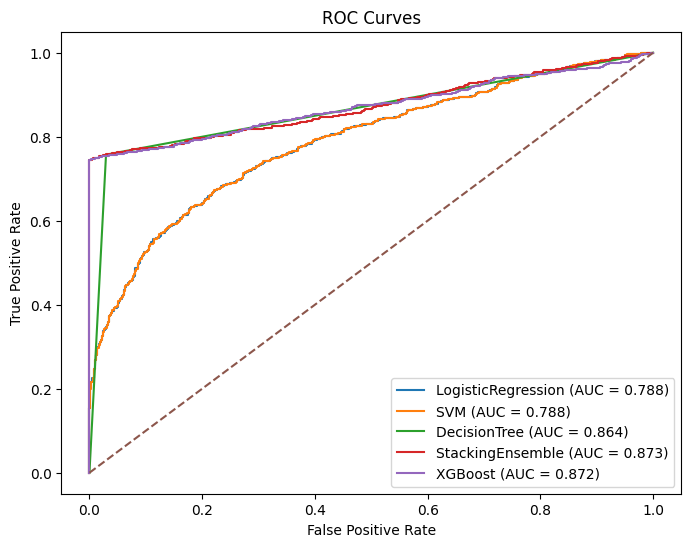

In [6]:
# === Imports ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC # Added LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier # Added DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer # Added for handling NaNs
import joblib
from google.colab import files
import io # Added for reading uploaded bytes

# Optional: XGBoost (if installed)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# === Helper functions ===

def prepare_features(df, binary=True):
    """Preprocess NSL-KDD DataFrame.
    - Converts textual categorical features to numeric (one-hot or label encode where appropriate)
    - Scales numeric features
    - For simplicity, this returns X, y for a binary classification (normal vs attack) when binary=True.
    """
    df = df.copy()

    # If label column name differs, set here. Common names: 'label' or 'attack'.
    label_col = 'label' if 'label' in df.columns else 'class' if 'class' in df.columns else df.columns[-1]

    print(f"Inferred label column: {label_col}")
    print(f"Unique values in original label column: {df[label_col].unique()}")

    # Convert multi-class attack labels to binary: 'normal' vs 'attack'
    if binary:
        # If the label column is already numeric and binary (0/1), use it directly
        if pd.api.types.is_numeric_dtype(df[label_col]) and df[label_col].isin([0, 1]).all():
            df['target'] = df[label_col].astype(int)
        else:
            # Fallback to string-based conversion for other types of labels
            df['target'] = df[label_col].apply(lambda x: 0 if str(x).lower() in ['normal', 'normal.'] else 1)
    else:
        df['target'] = df[label_col]

    print(f"Unique values in binary target column: {df['target'].unique()}")
    print(f"Counts of unique values in binary target column:\n{df['target'].value_counts()}")

    # Identify categorical columns (protocol_type, service, flag are typical examples)
    cat_cols = [c for c in df.columns if df[c].dtype == 'object' and c != label_col and c != 'target']
    num_cols = [c for c in df.columns if c not in cat_cols + [label_col, 'target']]

    # Convert any inf values to NaN to handle them with imputer
    df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

    # Build preprocessing pipeline
    # Numeric pipeline: Impute NaNs, then scale
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols)
        ], remainder='drop')

    X = preprocessor.fit_transform(df)
    y = df['target'].values

    # Save feature names (approximate)
    try:
        cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
        feature_names = list(num_cols) + list(cat_feature_names)
    except Exception:
        feature_names = None

    return X, y, preprocessor, feature_names


def evaluate_model(model, X_test, y_test, model_name='model'):
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    print(f"=== Evaluation: {model_name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    if auc is not None:
        print(f"AUC-ROC: {auc:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print('\n')

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}


# === Main pipeline ===
if __name__ == '__main__':
    # Step 1: Upload dataset files directly from local machine
    print("Please upload your NSL_KDD_Train.csv and (optionally) NSL_KDD_Test.csv files. Or any other CSV files.")
    uploaded = files.upload()

    csv_files = [f for f in uploaded.keys() if f.endswith('.csv')]

    if not csv_files:
        print("Error: No CSV file uploaded. Please upload at least one CSV file.")
        raise SystemExit

    df_list = []
    # Try to load the first CSV as training data
    df_train = pd.read_csv(io.BytesIO(uploaded[csv_files[0]]))
    df_list.append(df_train)
    print(f"Loaded training data from: {csv_files[0]}")

    # If there's a second CSV, treat it as test data and concatenate
    if len(csv_files) > 1:
        df_test = pd.read_csv(io.BytesIO(uploaded[csv_files[1]]))
        df_list.append(df_test)
        print(f"Loaded test data from: {csv_files[1]}")
    else:
        print("Note: Only one CSV file uploaded. Proceeding with only training data.")

    df = pd.concat(df_list, ignore_index=True)

    print("\nWarning: The subsequent preprocessing and model training steps are specifically designed for the NSL-KDD dataset format. If you uploaded a different dataset, these steps might fail or produce unexpected results.")


    # Step 2: Preprocess
    X, y, preprocessor, feature_names = prepare_features(df, binary=True)

    # Step 3: Train/test split (stratified)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    # Step 4: Define base models
    models = {}
    models['LogisticRegression'] = LogisticRegression(max_iter=500)
    models['SVM'] = LinearSVC(max_iter=1000, random_state=42) # Changed from SVC to LinearSVC for speed
    # Removed RandomForest: models['RandomForest'] = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    models['DecisionTree'] = DecisionTreeClassifier(random_state=42) # Replaced GradientBoosting with DecisionTree
    if HAS_XGB:
        models['XGBoost'] = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    # Removed MLP

    # Step 5: Fit models and evaluate
    results = {}
    os.makedirs('models', exist_ok=True) # Ensure models directory exists before saving
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        res = evaluate_model(model, X_test, y_test, model_name=name)
        results[name] = res
        # Save model
        joblib.dump({'model': model, 'preprocessor': preprocessor}, f'models/{name}.joblib')

    # Step 6: Ensemble - Stacking
    # Choose a subset of trained estimators (avoid including MLP due to probability calibration sometimes)
    estimators_for_stack = [
        ('lr', models['LogisticRegression']),
        ('svm', models['SVM']),
        ('dt', models['DecisionTree']) # Changed from RandomForest to DecisionTree
    ]
    # If XGBoost is available and was trained, add it to the stack as well
    if HAS_XGB and 'XGBoost' in models:
        estimators_for_stack.append(('xgb', models['XGBoost']))

    stack_clf = StackingClassifier(estimators=estimators_for_stack, final_estimator=LogisticRegression(), cv=5, n_jobs=-1, passthrough=False)
    print("Training StackingClassifier...")
    stack_clf.fit(X_train, y_train)
    res_stack = evaluate_model(stack_clf, X_test, y_test, model_name='StackingEnsemble')
    results['StackingEnsemble'] = res_stack
    joblib.dump({'model': stack_clf, 'preprocessor': preprocessor}, 'models/stacking.joblib')




    # Step 8: Summary of results
    print("\n=== Summary of all models ===")
    summary_df = pd.DataFrame(results).T
    print(summary_df)
    summary_df.to_csv('results_summary.csv', index=True)

    print("All models trained and saved in the models/ folder. Summary saved to results_summary.csv.")

    # Step 9: Plot ROC for best models (requires probabilities)
    try:
        import matplotlib.pyplot as plt
        from sklearn.metrics import roc_curve, auc

        plt.figure(figsize=(8,6))

        plot_models = ['LogisticRegression', 'SVM', 'DecisionTree', 'StackingEnsemble']
        if HAS_XGB:
            plot_models.append('XGBoost')

        for name in plot_models:
            mdl = None
            if name == 'StackingEnsemble':
                mdl = stack_clf
            elif name in models:
                mdl = models[name]

            if mdl is None: continue # Skip if model not in results or stack_clf

            # Check if the model has predict_proba or decision_function
            if hasattr(mdl, 'predict_proba'):
                y_proba = mdl.predict_proba(X_test)[:,1]
            elif hasattr(mdl, 'decision_function'):
                y_proba = mdl.decision_function(X_test)
            else:
                # For models like LinearSVC or DecisionTree without direct probabilities, skip ROC for now
                print(f"Skipping ROC plot for {name} (no probability or decision function available).")
                continue

            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

        plt.plot([0,1],[0,1],'--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves')
        plt.legend()
        plt.savefig('roc_curves.png')
        plt.show()
    except Exception as e:
        print("Could not plot ROC curves:", e)

# End of script
